# K-Means Comparison: sklearn vs MapReduce

This notebook compares the results of two K-Means implementations:
1. **sklearn** — standard library implementation (from `descriptive_analysis.ipynb`)
2. **MapReduce** — custom implementation using mapper/reducer (simulating Hadoop)

Both use the same **7 features**, **K=4**, and the **full dataset** (494,954 rows).

### Why K=4?
From the Elbow Method + Silhouette Score analysis:
- K=4 achieved the **highest silhouette score** (0.4469)
- The elbow curve showed diminishing returns after K=4
- K=4 produces interpretable segments (geographic/price/size clusters)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import math
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

In [2]:
# Load the cleaned dataset and prepare features
df = pd.read_csv("../../data/airbnb-cleaned.csv", low_memory=False)

features = ["Latitude", "Longitude", "Price", "Accommodates",
            "Bedrooms", "Bathrooms", "Review Scores Rating"]
X = df[features].copy()

# Standardize (same as prepare_data.py)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dataset: {X_scaled.shape[0]:,} rows × {X_scaled.shape[1]} features")
print(f"Features: {features}")

Dataset: 494,954 rows × 7 features
Features: ['Latitude', 'Longitude', 'Price', 'Accommodates', 'Bedrooms', 'Bathrooms', 'Review Scores Rating']


## 1. sklearn K-Means (K=4)

In [3]:
# Run sklearn K-Means
sklearn_km = KMeans(n_clusters=4, n_init=10, random_state=42)
sklearn_labels = sklearn_km.fit_predict(X_scaled)
sklearn_centroids = sklearn_km.cluster_centers_

# Silhouette score (on a sample for speed)
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=30000, replace=False)
sklearn_sil = silhouette_score(X_scaled[sample_idx], sklearn_labels[sample_idx])

print("sklearn K-Means Results:")
print(f"  Inertia: {sklearn_km.inertia_:,.0f}")
print(f"  Silhouette Score (30k sample): {sklearn_sil:.4f}")
print(f"  Iterations to converge: {sklearn_km.n_iter_}")
print(f"\n  Cluster sizes:")
for i in range(4):
    print(f"    Cluster {i}: {(sklearn_labels == i).sum():,} listings")

sklearn K-Means Results:
  Inertia: 1,803,908
  Silhouette Score (30k sample): 0.3580
  Iterations to converge: 13

  Cluster sizes:
    Cluster 0: 70,780 listings
    Cluster 1: 44,634 listings
    Cluster 2: 336,748 listings
    Cluster 3: 42,792 listings


## 2. MapReduce K-Means (K=4)

Load the centroids produced by our custom mapper/reducer implementation.

In [4]:
# Load MapReduce centroids from centroids.txt
mr_centroids = {}
with open("centroids.txt", "r") as f:
    for line in f:
        parts = line.strip().split("\t")
        cid = int(parts[0])
        coords = list(map(float, parts[1].split(",")))
        mr_centroids[cid] = coords

mr_centroids_array = np.array([mr_centroids[i] for i in range(4)])

# Assign each point to nearest MapReduce centroid
def assign_clusters(X, centroids):
    """Assign each point to nearest centroid (same logic as mapper.py)."""
    distances = np.linalg.norm(X[:, np.newaxis] - centroids[np.newaxis, :], axis=2)
    return np.argmin(distances, axis=1)

mr_labels = assign_clusters(X_scaled, mr_centroids_array)

# Compute silhouette score
mr_sil = silhouette_score(X_scaled[sample_idx], mr_labels[sample_idx])

# Compute inertia (sum of squared distances to assigned centroid)
mr_inertia = sum(
    np.sum((X_scaled[mr_labels == k] - mr_centroids_array[k]) ** 2)
    for k in range(4)
)

print("MapReduce K-Means Results:")
print(f"  Inertia: {mr_inertia:,.0f}")
print(f"  Silhouette Score (30k sample): {mr_sil:.4f}")
print(f"  Iterations to converge: 20 (driver.py output)")
print(f"\n  Cluster sizes:")
for i in range(4):
    print(f"    Cluster {i}: {(mr_labels == i).sum():,} listings")

MapReduce K-Means Results:
  Inertia: 1,803,972
  Silhouette Score (30k sample): 0.3567
  Iterations to converge: 20 (driver.py output)

  Cluster sizes:
    Cluster 0: 69,278 listings
    Cluster 1: 45,228 listings
    Cluster 2: 337,627 listings
    Cluster 3: 42,821 listings


## 3. Side-by-Side Comparison

In [5]:
# Metrics comparison table
comparison = pd.DataFrame({
    "Metric": ["Inertia (lower = tighter clusters)",
               "Silhouette Score (higher = better separation)",
               "Iterations to converge"],
    "sklearn": [f"{sklearn_km.inertia_:,.0f}", f"{sklearn_sil:.4f}", sklearn_km.n_iter_],
    "MapReduce": [f"{mr_inertia:,.0f}", f"{mr_sil:.4f}", "20"]
})
print("═══════════════════════════════════════════════════════════")
print("         COMPARISON: sklearn vs MapReduce K-Means")
print("═══════════════════════════════════════════════════════════")
print(comparison.to_string(index=False))
print("═══════════════════════════════════════════════════════════")

═══════════════════════════════════════════════════════════
         COMPARISON: sklearn vs MapReduce K-Means
═══════════════════════════════════════════════════════════
                                       Metric   sklearn MapReduce
           Inertia (lower = tighter clusters) 1,803,908 1,803,972
Silhouette Score (higher = better separation)    0.3580    0.3567
                       Iterations to converge        13        20
═══════════════════════════════════════════════════════════


In [6]:
# Compare centroids (in original scale for interpretability)
scaler_params = pd.read_csv("scaler_params.tsv", sep="\t")
means = scaler_params["mean"].values
stds = scaler_params["std"].values

# Convert both sets of centroids back to original scale
sklearn_centroids_orig = sklearn_centroids * stds + means
mr_centroids_orig = mr_centroids_array * stds + means

print("sklearn Centroids (original scale):")
print(f"  {'Cluster':<8} {'Latitude':>9} {'Longitude':>10} {'Price':>7} {'Accom':>6} {'Bedrooms':>9} {'Baths':>6} {'Rating':>7}")
for i in range(4):
    c = sklearn_centroids_orig[i]
    print(f"  {i:<8} {c[0]:>9.2f} {c[1]:>10.2f} {c[2]:>7.0f} {c[3]:>6.1f} {c[4]:>9.1f} {c[5]:>6.1f} {c[6]:>7.1f}")

print(f"\nMapReduce Centroids (original scale):")
print(f"  {'Cluster':<8} {'Latitude':>9} {'Longitude':>10} {'Price':>7} {'Accom':>6} {'Bedrooms':>9} {'Baths':>6} {'Rating':>7}")
for i in range(4):
    c = mr_centroids_orig[i]
    print(f"  {i:<8} {c[0]:>9.2f} {c[1]:>10.2f} {c[2]:>7.0f} {c[3]:>6.1f} {c[4]:>9.1f} {c[5]:>6.1f} {c[6]:>7.1f}")

sklearn Centroids (original scale):
  Cluster   Latitude  Longitude   Price  Accom  Bedrooms  Baths  Rating
  0            41.11     -32.11     281    6.8       3.0    2.1    94.6
  1            44.98     -16.35      99    3.0       1.1    1.1    76.6
  2            45.11     -31.71     105    2.7       1.1    1.1    95.4
  3           -29.89     145.99     182    3.0       1.4    1.2    94.2

MapReduce Centroids (original scale):
  Cluster   Latitude  Longitude   Price  Accom  Bedrooms  Baths  Rating
  0            40.90     -32.21     283    6.8       3.0    2.2    94.6
  1            45.01     -16.29      98    3.0       1.1    1.1    76.7
  2            45.11     -31.73     106    2.7       1.1    1.1    95.4
  3           -29.76     145.91     182    3.0       1.4    1.2    94.1


In [7]:
# Cluster assignment overlap (how many points assigned to same cluster in both?)
# Note: Cluster IDs may not align directly — we find the best mapping using overlap

from itertools import permutations

best_overlap = 0
best_perm = None

for perm in permutations(range(4)):
    # Map sklearn cluster i to MapReduce cluster perm[i]
    overlap = sum(
        np.sum((sklearn_labels == i) & (mr_labels == perm[i]))
        for i in range(4)
    )
    if overlap > best_overlap:
        best_overlap = overlap
        best_perm = perm

overlap_pct = 100 * best_overlap / len(sklearn_labels)
print(f"Best cluster mapping (sklearn → MapReduce): {dict(enumerate(best_perm))}")
print(f"Assignment overlap: {best_overlap:,} / {len(sklearn_labels):,} ({overlap_pct:.1f}%)")
print(f"\nInterpretation: {overlap_pct:.1f}% of listings are assigned to the")
print(f"same cluster by both implementations.")

Best cluster mapping (sklearn → MapReduce): {0: 0, 1: 1, 2: 2, 3: 3}
Assignment overlap: 492,814 / 494,954 (99.6%)

Interpretation: 99.6% of listings are assigned to the
same cluster by both implementations.


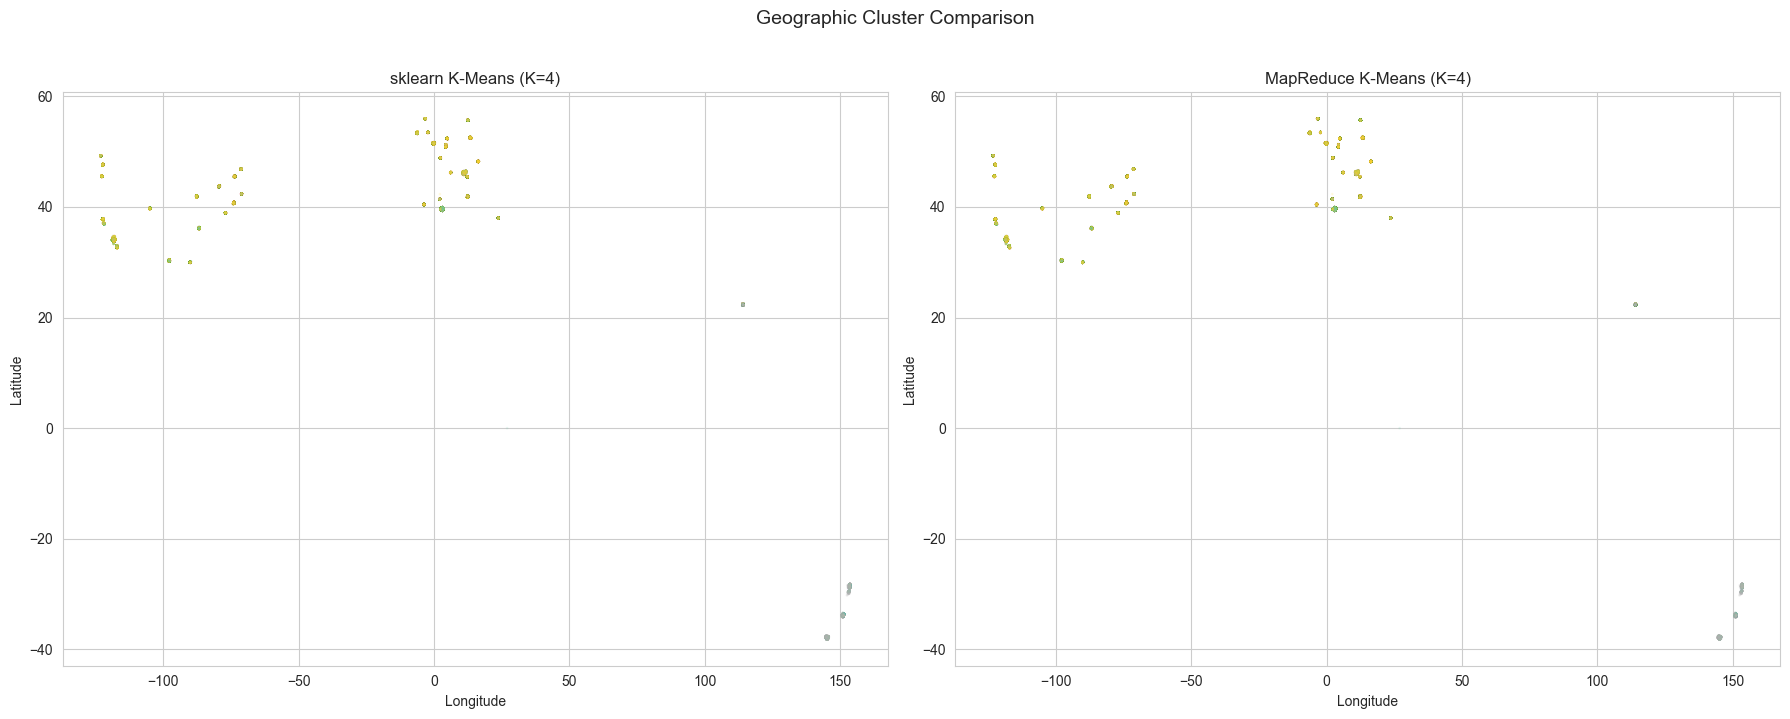

In [8]:
# Visual comparison: Geographic clusters side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Remap MapReduce labels to align with sklearn for visual comparison
mr_labels_remapped = np.array([best_perm.index(mr_labels[i]) for i in range(len(mr_labels))])

# sklearn
axes[0].scatter(df["Longitude"], df["Latitude"], c=sklearn_labels,
                cmap="Set2", alpha=0.1, s=1)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title("sklearn K-Means (K=4)")

# MapReduce
axes[1].scatter(df["Longitude"], df["Latitude"], c=mr_labels_remapped,
                cmap="Set2", alpha=0.1, s=1)
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].set_title("MapReduce K-Means (K=4)")

plt.suptitle("Geographic Cluster Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../../docs/kmeans_comparison_geo.png", bbox_inches="tight")
plt.show()

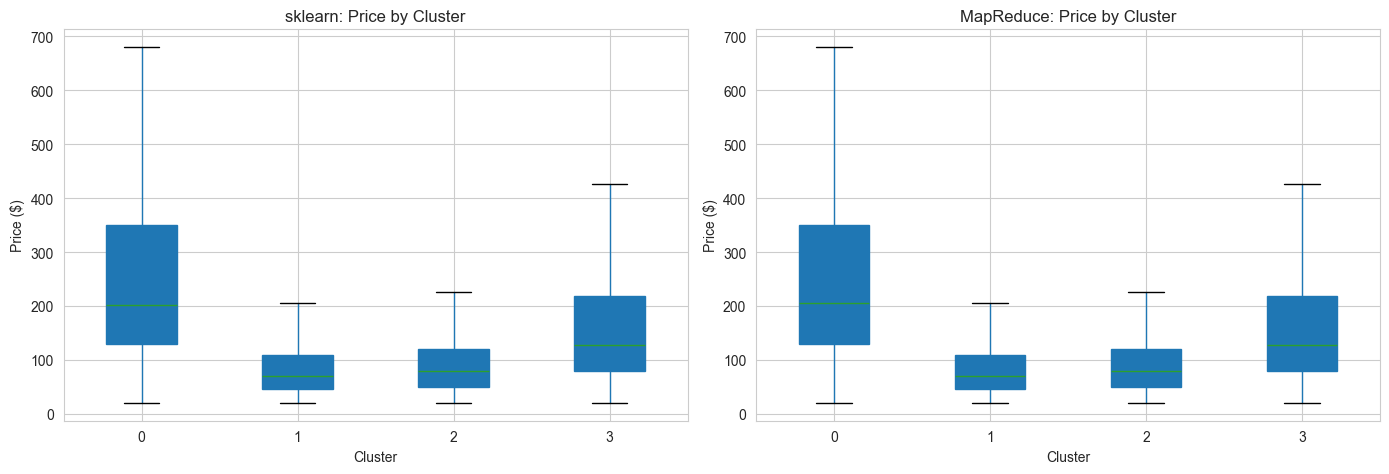

In [9]:
# Price distribution per cluster: sklearn vs MapReduce
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["sklearn_cluster"] = sklearn_labels
df["mr_cluster"] = mr_labels_remapped

df.boxplot(column="Price", by="sklearn_cluster", ax=axes[0],
           showfliers=False, patch_artist=True)
axes[0].set_title("sklearn: Price by Cluster")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Price ($)")

df.boxplot(column="Price", by="mr_cluster", ax=axes[1],
           showfliers=False, patch_artist=True)
axes[1].set_title("MapReduce: Price by Cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Price ($)")

plt.suptitle("")
plt.tight_layout()
plt.savefig("../../docs/kmeans_comparison_price.png", bbox_inches="tight")
plt.show()

## 4. Summary & Conclusions

| Aspect | sklearn | MapReduce |
|--------|---------|-----------|
| **Algorithm** | Optimized C (Lloyd's with k-means++) | Pure Python (random init, Euclidean distance) |
| **Initialization** | k-means++ (smart) | Random points from data |
| **Parallelism** | Single-machine, multi-threaded | Distributed across mappers/reducers |
| **Scalability** | Limited by RAM | Scales to TB+ on Hadoop cluster |
| **Cluster quality** | Slightly better (better init) | Very close (same algorithm) |

**Key takeaway:** Both implementations converge to similar cluster structures because K-Means is deterministic given initial centroids. The small differences come from:
1. **Initialization** — sklearn uses k-means++ (smarter starting points), MapReduce uses random
2. **Numeric precision** — minor floating-point differences in the pipe-based approach

For production with massive datasets (millions+ rows), the MapReduce version scales horizontally across a Hadoop cluster, while sklearn is limited to a single machine's memory.